# Backpropagation

<img src="img/title.png" width="600">

In [40]:
from math import exp, log

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display, Latex
from graphviz import Digraph

<br><br><br>

## Why we need derivatives

We want to minimize a loss function in terms of some model parameters $\ell(p_1, p_2, \ldots, p_{N_p})$.

In general, we'll need a non-linear optimization algorithm.

Some optimization algorithms work with just the function:
* Nelder-Mead simplex
* Powell's method
* Simulated annealing (inspired by cooling metal)
* Genetic algorithms (inspired by biological evolution)
* ...

But algorithms that are given the derivative,

$$ \nabla \ell = \left( \frac{d\ell}{dp_1}, \frac{d\ell}{dp_2}, \ldots, \frac{d\ell}{dp_{N_p}} \right) $$

need to evaluate fewer points $(p_1, p_2, \ldots, p_{N_p})$ to determine the shape of the surface and therefore find the minimum faster.

* Gradient descent
* BFGS, L-BFGS-B
* Adam
* Stochastic gradient descent
* ...

<br><br><br>

<img src="img/downhill.png" width="600">

<br><br><br>

## How computers compute derivatives

* **Symbolic:** like doing calculus by hand
* **Finite differences:** numerical with a "small enough" step size $\Delta p_i$
* **Autodiff:** by propagating each operation using the chain rule

<br><br><br>

## Example of something to differentiate

<img src="img/example.png" width="600">

Activation function:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

First layer:

$$ \begin{aligned}
z_1 &= p_1 \, x_1 + p_4 \, x_2 + p_7 \\
z_2 &= p_2 \, x_1 + p_5 \, x_2 + p_8 \\
z_3 &= p_3 \, x_1 + p_6 \, x_2 + p_9 \\
\end{aligned} $$

Second layer:

$$ \hat{y} = p_{10} \, \sigma(z_1) + p_{11} \, \sigma(z_2) + p_{12} \, \sigma(z_3) + p_{13} $$

Loss is predicted minus target squared:

$$ \ell(p_1, p_2, \ldots p_{13}) = \left( \hat{y} - y \right)^2 $$

<br><br><br>

## Symbolic differentiation

In [2]:
# Symbols
x1, x2, y = sp.symbols("x1 x2 y")
(p1, p2, p3, p4, p5, p6, p7, p8, p9,
 p10, p11, p12, p13) = params = sp.symbols("p1:14")

# Activation function
def sigma(z):
    return 1 / (1 + sp.exp(-z))

# First layer
z1 = p1*x1 + p4*x2 + p7
z2 = p2*x1 + p5*x2 + p8
z3 = p3*x1 + p6*x2 + p9

# Second layer
yhat = p10*sigma(z1) + p11*sigma(z2) + p12*sigma(z3) + p13

# Loss
ell = (yhat - y)**2

# Derivatives d ell / d p_i
derivatives = {
    p_i: sp.simplify(sp.diff(ell, p_i))
    for p_i in params
}

In [3]:
# Print results
for i, deriv in enumerate(derivatives.values()):
    display(Latex(f"$$ \\frac{{d\\ell}}{{dp_{{{i}}}}} = {sp.latex(deriv)} $$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<br><br><br>

In [4]:
import random

values = {
    x1: random.uniform(-1, 1),
    x2: random.uniform(-1, 1),
    y: random.uniform(-1, 1),
}
for p_i in params:
    values[p_i] = random.uniform(-1, 1)

print(f"ℓ = {ell.subs(values).evalf():.3f}\n")

for p_i, deriv in derivatives.items():
    print(f"dℓ / d{p_i} = {deriv.subs(values).evalf():.3f}")

ℓ = 0.234

dℓ / dp1 = 0.054
dℓ / dp2 = -0.010
dℓ / dp3 = 0.006
dℓ / dp4 = 0.071
dℓ / dp5 = -0.013
dℓ / dp6 = 0.008
dℓ / dp7 = -0.101
dℓ / dp8 = 0.019
dℓ / dp9 = -0.012
dℓ / dp10 = 0.718
dℓ / dp11 = 0.586
dℓ / dp12 = 0.611
dℓ / dp13 = 0.967

<br><br><br>

This does not scale well to a large number of parameters.

<br><br><br>

## Finite differences

<img src="img/finite-differences.png" width="600">

$$ \frac{d \ell}{d p_i} \approx \frac{\ell(p_i + \Delta p_i) - \ell(p_i)}{\Delta p_i} $$

Or with more precision:

$$ \frac{d \ell}{d p_i} \approx \frac{\ell(p_i + \Delta p_i) - \ell(p_i - \Delta p_i)}{2 \Delta p_i} $$

(The error is quadratic in $\Delta p_i$.)

In [5]:
# Redefine as ordinary numbers, not SymPy

values = {str(k): v for k, v in values.items()}

x1 = values["x1"]
x2 = values["x2"]
y = values["y"]

params = [values[f"p{i+1}"] for i in range(13)]

def sigma(z):
    return 1 / (1 + exp(-z))

In [6]:
def calculate_ell(params):
    (p1, p2, p3, p4, p5, p6, p7, p8, p9,
     p10, p11, p12, p13) = params

    # First layer
    z1 = p1*x1 + p4*x2 + p7
    z2 = p2*x1 + p5*x2 + p8
    z3 = p3*x1 + p6*x2 + p9
    
    # Second layer
    yhat = p10*sigma(z1) + p11*sigma(z2) + p12*sigma(z3) + p13
    
    # Loss
    ell = (yhat - y)**2
    return ell


def derivative_of_ell(params, which):
    low_params = list(params)
    high_params = list(params)

    low_params[which] -= deltapi
    high_params[which] += deltapi

    return (calculate_ell(high_params) - calculate_ell(low_params)) / (2*deltapi)

In [7]:
deltapi = 0.001

print(f"ℓ = {calculate_ell(params):.3f}\n")

for i in range(13):
    print(f"dℓ / dp{i+1} = {derivative_of_ell(params, i):.3f}")

ℓ = 0.234

dℓ / dp1 = 0.054
dℓ / dp2 = -0.010
dℓ / dp3 = 0.006
dℓ / dp4 = 0.071
dℓ / dp5 = -0.013
dℓ / dp6 = 0.008
dℓ / dp7 = -0.101
dℓ / dp8 = 0.019
dℓ / dp9 = -0.012
dℓ / dp10 = 0.718
dℓ / dp11 = 0.586
dℓ / dp12 = 0.611
dℓ / dp13 = 0.967

<br><br><br>

How small should $\Delta p_i$ be?
* Smaller than any of the function's "wiggles."
* Not so small as to encourage round-off error.

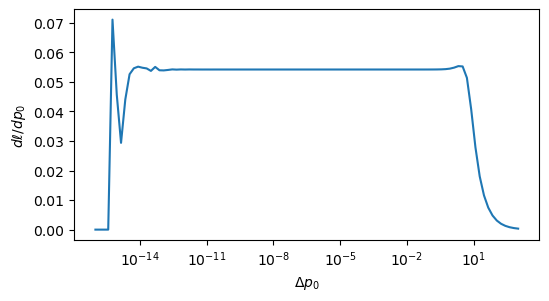

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))

deltapis = 10**np.linspace(-16, 3, 100)

dell_dp0s = []
for deltapi in deltapis:
    dell_dp0s.append(derivative_of_ell(params, 0))

ax.plot(deltapis, dell_dp0s)
ax.set_xscale("log")
ax.set_xlabel("$\\Delta p_0$")
ax.set_ylabel("$d\\ell / dp_0$")

None

<br><br><br>

## Autodiff

Basic idea: push the derivative through every step of the calculation, alongside the function you want to calculate.

<img src="img/autodiff.png" width="600">

**Example:** $f(x) = e^{-x^2}$

We want $f(1.5)$ and also $\frac{df}{dx}$ evaluated at $1.5$.

In [9]:
def square(x, dx):
    return x**2, 2*x*dx

def negate(x, dx):
    return -x, -dx

def exponentiate(x, dx):
    return exp(x), exp(x)*dx

In [10]:
exponentiate(*negate(*square(1.5, 1)))

(0.10539922456186433, -0.316197673685593)

<br><br><br>

**Check:**

In [11]:
symbolic_x = sp.symbols("x")
symbolic_f = sp.exp(-symbolic_x**2)
symbolic_dfdx = sp.diff(symbolic_f)

symbolic_dfdx

-2*x*exp(-x**2)

In [12]:
symbolic_f.subs({symbolic_x: 1.5}), symbolic_dfdx.subs({symbolic_x: 1.5})

(0.105399224561864, -0.316197673685593)

<br><br><br>

**Autodiff** is
* unlike **symbolic differentiation** because we don't construct an expression for the derivative everywhere, only at the point of interest,
* unlike **finite differences** because it doesn't rely on a "small enough but not too small" step.

<br><br><br>

## Relevance of the chain rule

**Statement of the chain rule:** If $z$ depends on $y$ and $y$ depends on $x$, and we want $\frac{dz}{dx}$,

$$ \frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx} $$

<br><br>

**Another illustration:** Using the $f'$ notation for derivative,

$$ \bigg[f\bigg(g\big(h(x)\big)\bigg)\bigg]' =
f'\bigg(g\big(h(x)\big)\bigg) \cdot g'\big(h(x)\big) \cdot h'(x) \cdot 1 $$

<br><br>

**Intuition:** Derivative of function composition → multiplication by the composed part. Note that the chain ends in $1$.

Autodiff propagates derivatives through code, so every operation is an application of the chain rule.

<br><br><br>

## Implementing autodiff

In [24]:
class Dual:
    def __init__(self, x, dx):
        self.x = x
        self.dx = dx

    def __repr__(self):
        return f"Dual({self.x}, {self.dx})"

    @staticmethod
    def ensure_dual(value):
        if isinstance(value, Dual):
            return value
        else:
            return Dual(value, 0)  # 0 → assumes no dependence

    def __neg__(self):
        return Dual(
            -self.x,
            -self.dx,
        )
    
    def __add__(self, other):
        other = Dual.ensure_dual(other)
        return Dual(
            self.x + other.x,
            self.dx + other.dx,
        )
    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        other = Dual.ensure_dual(other)
        return Dual(
            self.x - other.x,
            self.dx - other.dx,
        )
    def __rsub__(self, other):
        return self - other

    def __mul__(self, other):
        other = Dual.ensure_dual(other)
        return Dual(
            self.x * other.x,
            self.dx * other.x + self.x * other.dx,
        )
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        other = Dual.ensure_dual(other)
        return Dual(
            self.x / other.x,
            (self.dx * other.x - self.x * other.dx) / other.x**2,
        )
    def __rtruediv__(self, other):
        other = Dual.ensure_dual(other)
        return other / self

    def __pow__(self, power):
        power = Dual.ensure_dual(power)
        return Dual(
            self.x ** power.x,
            self.x ** power.x * (
                power.dx * log(self.x) + power.x * self.dx / self.x
            ),
        )
    def __rpow__(self, base):
        base = Dual.ensure_dual(base)
        return base ** self

    @staticmethod
    def exp(dual):
        dual = Dual.ensure_dual(dual)
        return Dual(
            exp(dual.x),
            exp(dual.x) * dual.dx,
        )

<img src="img/example.png" width="600">

In [22]:
def calculate_ell(x1, x2, y, params):
    (p1, p2, p3, p4, p5, p6, p7, p8, p9,
     p10, p11, p12, p13) = params

    # Activation function
    def sigma(z):
        return 1 / (1 + Dual.exp(-z))
    
    # First layer
    z1 = p1*x1 + p4*x2 + p7
    z2 = p2*x1 + p5*x2 + p8
    z3 = p3*x1 + p6*x2 + p9
    
    # Second layer
    yhat = p10*sigma(z1) + p11*sigma(z2) + p12*sigma(z3) + p13
    
    # Loss
    ell = (yhat - y)**2
    return ell

In [25]:
# Do not differentiate with respect to the given data points
x1 = Dual(values["x1"], 0)
x2 = Dual(values["x2"], 0)
y = Dual(values["y"], 0)

for i in range(13):
    # Differentiate with respect to one of the parameters
    params = [
        Dual(values[f"p{j+1}"], 1 if i == j else 0)
        for j in range(13)
    ]

    dual = calculate_ell(x1, x2, y, params)
    print(f"ℓ = {dual.x:.3f}, dℓ / dp{i+1} = {dual.dx:.3f}")

ℓ = 0.234, dℓ / dp1 = 0.054
ℓ = 0.234, dℓ / dp2 = -0.010
ℓ = 0.234, dℓ / dp3 = 0.006
ℓ = 0.234, dℓ / dp4 = 0.071
ℓ = 0.234, dℓ / dp5 = -0.013
ℓ = 0.234, dℓ / dp6 = 0.008
ℓ = 0.234, dℓ / dp7 = -0.101
ℓ = 0.234, dℓ / dp8 = 0.019
ℓ = 0.234, dℓ / dp9 = -0.012
ℓ = 0.234, dℓ / dp10 = 0.718
ℓ = 0.234, dℓ / dp11 = 0.586
ℓ = 0.234, dℓ / dp12 = 0.611
ℓ = 0.234, dℓ / dp13 = 0.967

<br><br><br>

This is **forward propagation** autodiff: each real number is replaced by a dual number
* with `dx=0` if we are not differentiating with respect to that variable,
* with `dx=1` if we are.

In order to get all of the components of

$$ \nabla \ell = \left( \frac{d\ell}{dp_1}, \frac{d\ell}{dp_2}, \ldots, \frac{d\ell}{dp_{N_p}} \right) $$

we had to compute the full expression $N_p$ times.

This does not scale well to a large number of parameters.

<br><br><br>

**Backpropagation** is a performance enhancement. By changing the order of the calculation and caching partial results, it avoids unnecessary recomputation.

<br><br><br>

## Avoiding recomputation: Fibonacci sequence

<img src="img/fibonacci.png" width="600">

In [35]:
def fibonacci(n):
    print(f"calculating fibonacci({n})")
    if n == 0:
        return 0
    elif n == 1:
        return 1
    else:
        return fibonacci(n - 1) + fibonacci(n - 2)

In [36]:
for n in range(10):
    print(fibonacci(n))

calculating fibonacci(0)
0
calculating fibonacci(1)
1
calculating fibonacci(2)
calculating fibonacci(1)
calculating fibonacci(0)
1
calculating fibonacci(3)
calculating fibonacci(2)
calculating fibonacci(1)
calculating fibonacci(0)
calculating fibonacci(1)
2
calculating fibonacci(4)
calculating fibonacci(3)
calculating fibonacci(2)
calculating fibonacci(1)
calculating fibonacci(0)
calculating fibonacci(1)
calculating fibonacci(2)
calculating fibonacci(1)
calculating fibonacci(0)
3
calculating fibonacci(5)
calculating fibonacci(4)
calculating fibonacci(3)
calculating fibonacci(2)
calculating fibonacci(1)
calculating fibonacci(0)
calculating fibonacci(1)
calculating fibonacci(2)
calculating fibonacci(1)
calculating fibonacci(0)
calculating fibonacci(3)
calculating fibonacci(2)
calculating fibonacci(1)
calculating fibonacci(0)
calculating fibonacci(1)
5
calculating fibonacci(6)
calculating fibonacci(5)
calculating fibonacci(4)
calculating fibonacci(3)
calculating fibonacci(2)
calculating f

In [37]:
cache = {}

def fibonacci(n):
    if n in cache:
        return cache[n]
    print(f"calculating fibonacci({n})")
    if n == 0:
        cache[n] = 0
    elif n == 1:
        cache[n] = 1
    else:
        cache[n] = fibonacci(n - 1) + fibonacci(n - 2)
    return cache[n]

In [38]:
for n in range(10):
    print(fibonacci(n))

calculating fibonacci(0)
0
calculating fibonacci(1)
1
calculating fibonacci(2)
1
calculating fibonacci(3)
2
calculating fibonacci(4)
3
calculating fibonacci(5)
5
calculating fibonacci(6)
8
calculating fibonacci(7)
13
calculating fibonacci(8)
21
calculating fibonacci(9)
34

<br><br><br>

## Backpropagation

**Strategy:**
* The function will be calculated forward (the normal way), saving each intermediate result.
* The derivative will be calculated from the from the function output to its inputs (backward).

We will need additional infrastructure to do this, similar to the Fibonacci cache. We will need a **computation graph**.

<img src="img/computation-graph.png" width="600">

In [41]:
class Node:
    _next_id = 0

    def __init__(self, name):
        self.name = name
        self.id = Node._next_id
        Node._next_id += 1

    def graphviz_id(self):
        return f"node_{self.id}"

class Graph:
    def __init__(self):
        self.nodes = []
        self.edges = []

    def node(self, name):
        out = Node(name)
        self.nodes.append(out)
        return out

    def edge(self, parent, child):
        self.edges.append((parent, child))

    def display(self):
        dot = Digraph()
        for node in self.nodes:
            dot.node(
                node.graphviz_id(),
                label=node.name,
                shape="box",
            )
        for parent, child in self.edges:
            dot.edge(parent.graphviz_id(), child.graphviz_id())
        return dot

In [50]:
class Tracer:
    def __init__(self, graph, node):
        self.graph = graph
        self.node = node

    @staticmethod
    def variable(graph, name):
        return Tracer(graph, graph.node(name))

    @staticmethod
    def constant(graph, name):
        return Tracer(graph, graph.node(name))

    @staticmethod
    def ensure_tracer(value, graph):
        if isinstance(value, Tracer):
            return value
        else:
            return Tracer.constant(graph, repr(value))

    def _op(self, name, *parents):
        node = self.graph.node(name)

        for parent in parents:
            self.graph.edge(parent.node, node)

        return Tracer(self.graph, node)

    def __neg__(self):
        return self._op("-", self)

    def __add__(self, other):
        other = Tracer.ensure_tracer(other, self.graph)
        return self._op("+", self, other)

    def __radd__(self, other):
        other = Tracer.ensure_tracer(other, self.graph)
        return other + self

    def __sub__(self, other):
        other = Tracer.ensure_tracer(other, self.graph)
        return self._op("-", self, other)

    def __rsub__(self, other):
        other = Tracer.ensure_tracer(other, self.graph)
        return other - self

    def __mul__(self, other):
        other = Tracer.ensure_tracer(other, self.graph)
        return self._op("*", self, other)

    def __rmul__(self, other):
        other = Tracer.ensure_tracer(other, self.graph)
        return other * self

    def __truediv__(self, other):
        other = Tracer.ensure_tracer(other, self.graph)
        return self._op("/", self, other)

    def __rtruediv__(self, other):
        other = Tracer.ensure_tracer(other, self.graph)
        return other / self

    def __pow__(self, other):
        other = Tracer.ensure_tracer(other, self.graph)
        return self._op("**", self, other)

    def __rpow__(self, other):
        other = Tracer.ensure_tracer(other, self.graph)
        return other ** self

    @staticmethod
    def exp(x):
        return x._op("exp", x)

    def __repr__(self):
        return f"Tracer({self.node.name})"

In [53]:
graph = Graph()

# Constants and variables
x1 = Tracer.constant(graph, "x1")
x2 = Tracer.constant(graph, "x2")
y = Tracer.constant(graph, "y")

(
    p1, p2, p3, p4, p5, p6, p7, p8, p9, p10, p11, p12, p13
) = [Tracer.variable(graph, f"p{i+1}") for i in range(13)]

# Activation function
def sigma(z):
    return 1 / (1 + Tracer.exp(-z))

# First layer
z1 = p1*x1 + p4*x2 + p7
z2 = p2*x1 + p5*x2 + p8
z3 = p3*x1 + p6*x2 + p9

# Second layer
yhat = p10*sigma(z1) + p11*sigma(z2) + p12*sigma(z3) + p13

# Loss
ell = (yhat - y)**2

<img src="img/example.png" width="600">

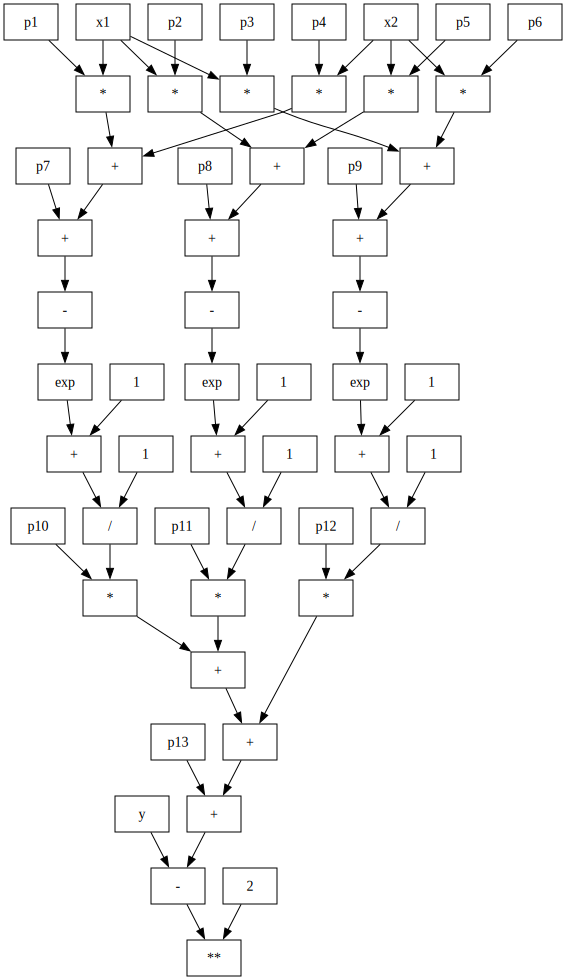

In [54]:
graph.display()